In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.monte_carlo import run_simulation

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
params = {
    "S0": 2000.0,
    "mu": 0.0,
    "sigma": 0.6,
    "Q": 1.0,
    "B0": 800.0,
    "LT": 0.8,
    "r_b": 0.02,
    "T": 1.0,
    "N": 252,
    "n_paths": 5000,
}

In [3]:
def analytical_liquidation_prob(params):
    HF0 = params["Q"] * params["S0"] * params["LT"] / params["B0"]
    D0 = np.log(HF0)
    
    sigma = params["sigma"]
    T = params["T"]
    
    z = D0 / (sigma * np.sqrt(T))
    
    return 2 * norm.cdf(-z)

In [4]:
sigma_grid = np.linspace(0.1, 1.0, 12)

sim_probs = []
ana_probs = []

for sigma in sigma_grid:
    p = params.copy()
    p["sigma"] = sigma

    # simulation
    res = run_simulation(p)
    sim_probs.append(res["liquidation_prob"])

    # analytical
    ana_probs.append(analytical_liquidation_prob(p))

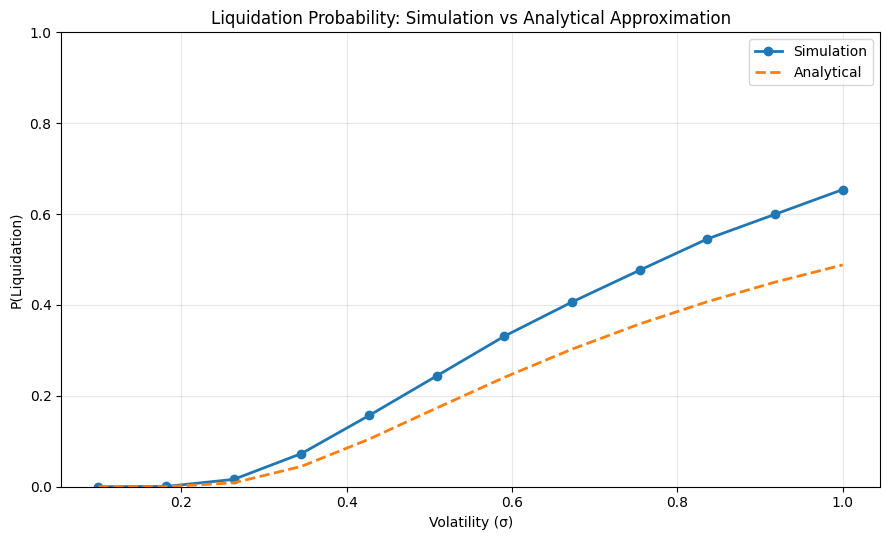

In [5]:
plt.figure(figsize=(9, 5.5))

plt.plot(sigma_grid, sim_probs, marker="o", label="Simulation", linewidth=2)
plt.plot(sigma_grid, ana_probs, linestyle="--", label="Analytical", linewidth=2)

plt.title("Liquidation Probability: Simulation vs Analytical Approximation")
plt.xlabel("Volatility (σ)")
plt.ylabel("P(Liquidation)")

plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

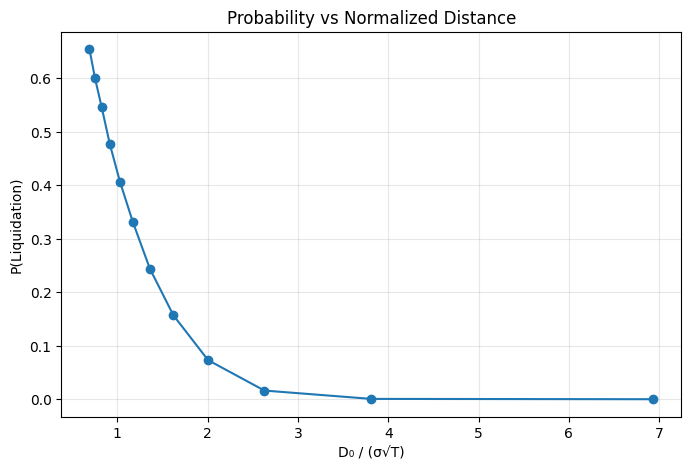

In [6]:
x_vals = []
sim_probs = []

for sigma in sigma_grid:
    p = params.copy()
    p["sigma"] = sigma

    res = run_simulation(p)

    HF0 = p["Q"] * p["S0"] * p["LT"] / p["B0"]
    D0 = np.log(HF0)

    x_vals.append(D0 / (sigma * np.sqrt(p["T"])))
    sim_probs.append(res["liquidation_prob"])

plt.figure(figsize=(8, 5))
plt.plot(x_vals, sim_probs, marker="o")

plt.title("Probability vs Normalized Distance")
plt.xlabel("D₀ / (σ√T)")
plt.ylabel("P(Liquidation)")

plt.grid(alpha=0.3)
plt.show()

In [ ]:
t_grid = np.linspace(0, params["T"], 100)
survival = np.array([(tau > t).mean() for t in t_grid])
dt = t_grid[1] - t_grid[0]
density = -np.gradient(survival, dt)
hazard = density / survival
hazard[survival < 1e-4] = np.nan

plt.figure(figsize=(8, 5))

plt.plot(t_grid, hazard, linewidth=2)

plt.title("Hazard Rate λ(t): Instantaneous Liquidation Risk")
plt.xlabel("Time")
plt.ylabel("Hazard Rate")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()